In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

In [20]:
dataset=pd.read_csv("iris.csv")
dataset.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [21]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal.length  150 non-null    float64
 1   sepal.width   150 non-null    float64
 2   petal.length  150 non-null    float64
 3   petal.width   150 non-null    float64
 4   variety       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [22]:
fields = dataset.iloc[:, [0, 1, 2, 3]].values
print(fields)

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

In [23]:
wcss = []
for index in range(1, 11):
    kmeans = KMeans(n_clusters=index, init="k-means++", random_state=2, n_init=10)
    kmeans.fit(fields)
    wcss.append(kmeans.inertia_)

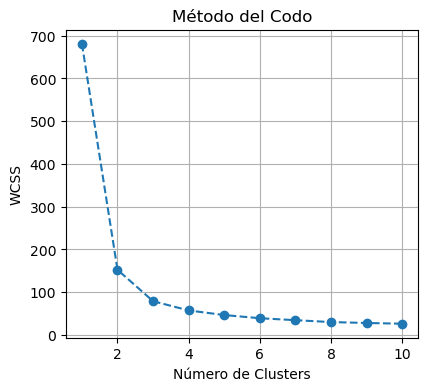

In [24]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Método del Codo')
plt.xlabel('Número de Clusters')
plt.ylabel('WCSS')
plt.grid(True)

In [25]:
silhouette_scores = []
for index in range(2, 11):
    kmeans = KMeans(n_clusters=index, init="k-means++", random_state=2, n_init=10)
    labels = kmeans.fit_predict(fields)
    silhouette_scores.append(silhouette_score(fields, labels))

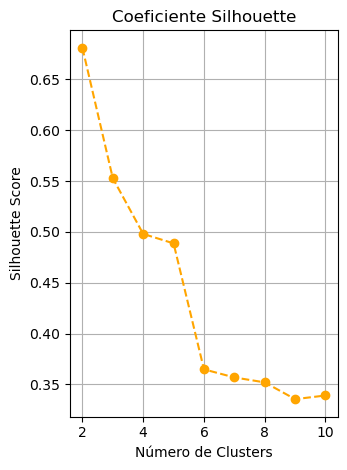

In [26]:
# Graficar Silhouette
plt.subplot(1, 2, 2)
plt.plot(range(2, 11), silhouette_scores, marker='o', linestyle='--', color='orange')
plt.title('Coeficiente Silhouette')
plt.xlabel('Número de Clusters')
plt.ylabel('Silhouette Score')
plt.grid(True)

plt.tight_layout()
plt.show()

In [27]:
print("\nWCSS por número de clusters:")
for i, w in enumerate(wcss, 1):
    print(f"Clusters: {i}, WCSS: {w:.2f}")

print("\nSilhouette Score por número de clusters:")
for i, s in enumerate(silhouette_scores, 2):
    print(f"Clusters: {i}, Silhouette: {s:.4f}")


WCSS por número de clusters:
Clusters: 1, WCSS: 681.37
Clusters: 2, WCSS: 152.35
Clusters: 3, WCSS: 78.85
Clusters: 4, WCSS: 57.23
Clusters: 5, WCSS: 46.45
Clusters: 6, WCSS: 39.04
Clusters: 7, WCSS: 34.42
Clusters: 8, WCSS: 30.02
Clusters: 9, WCSS: 27.90
Clusters: 10, WCSS: 26.14

Silhouette Score por número de clusters:
Clusters: 2, Silhouette: 0.6810
Clusters: 3, Silhouette: 0.5528
Clusters: 4, Silhouette: 0.4981
Clusters: 5, Silhouette: 0.4887
Clusters: 6, Silhouette: 0.3648
Clusters: 7, Silhouette: 0.3569
Clusters: 8, Silhouette: 0.3520
Clusters: 9, Silhouette: 0.3355
Clusters: 10, Silhouette: 0.3391


In [28]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [29]:
scaler = StandardScaler()
fields_scaled = scaler.fit_transform(fields)

pca = PCA(n_components=2)
fields_pca = pca.fit_transform(fields_scaled)

print(f"\nVarianza explicada por cada componente:")
print(f"PC1: {pca.explained_variance_ratio_[0]:.4f}")
print(f"PC2: {pca.explained_variance_ratio_[1]:.4f}")
print(f"Varianza total explicada: {sum(pca.explained_variance_ratio_):.4f}")


Varianza explicada por cada componente:
PC1: 0.7296
PC2: 0.2285
Varianza total explicada: 0.9581


In [34]:
wcss_pca = []
for index in range(1, 11):
    kmeans = KMeans(n_clusters=index, init="k-means++", random_state=2, n_init=10)
    kmeans.fit(fields_pca)
    wcss_pca.append(kmeans.inertia_)

silhouette_scores_pca = []
for index in range(2, 11):
    kmeans = KMeans(n_clusters=index, init="k-means++", random_state=2, n_init=10)
    labels = kmeans.fit_predict(fields_pca)
    silhouette_scores_pca.append(silhouette_score(fields_pca, labels))

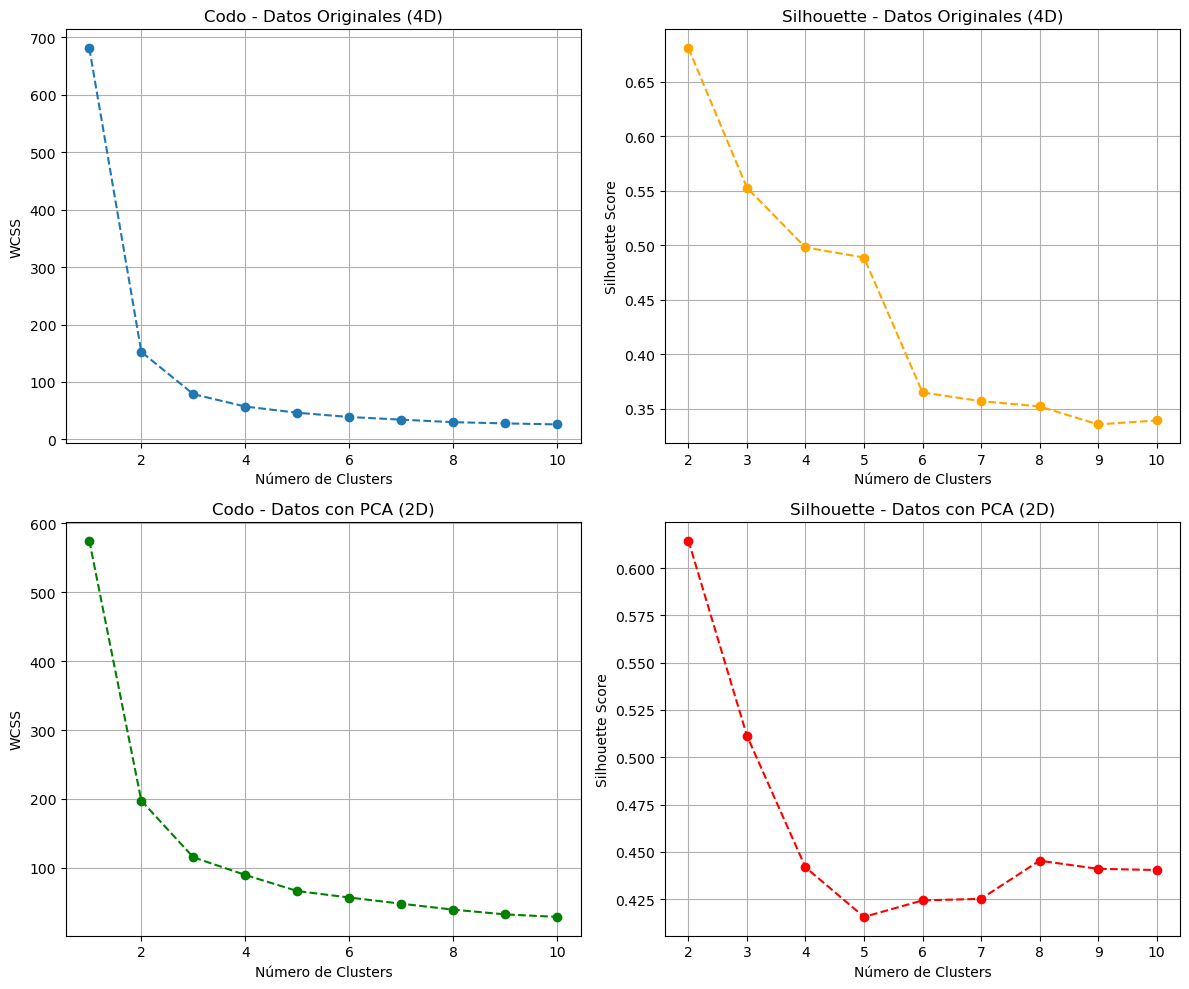

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Codo - Datos originales
axes[0, 0].plot(range(1, 11), wcss, marker='o', linestyle='--')
axes[0, 0].set_title('Codo - Datos Originales (4D)')
axes[0, 0].set_xlabel('Número de Clusters')
axes[0, 0].set_ylabel('WCSS')
axes[0, 0].grid(True)

# Silhouette - Datos originales
axes[0, 1].plot(range(2, 11), silhouette_scores, marker='o', linestyle='--', color='orange')
axes[0, 1].set_title('Silhouette - Datos Originales (4D)')
axes[0, 1].set_xlabel('Número de Clusters')
axes[0, 1].set_ylabel('Silhouette Score')
axes[0, 1].grid(True)

# Codo - Datos con PCA
axes[1, 0].plot(range(1, 11), wcss_pca, marker='o', linestyle='--', color='green')
axes[1, 0].set_title('Codo - Datos con PCA (2D)')
axes[1, 0].set_xlabel('Número de Clusters')
axes[1, 0].set_ylabel('WCSS')
axes[1, 0].grid(True)

# Silhouette - Datos con PCA
axes[1, 1].plot(range(2, 11), silhouette_scores_pca, marker='o', linestyle='--', color='red')
axes[1, 1].set_title('Silhouette - Datos con PCA (2D)')
axes[1, 1].set_xlabel('Número de Clusters')
axes[1, 1].set_ylabel('Silhouette Score')
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

In [36]:
print("\n=== COMPARATIVA WCSS ===")
print(f"{'k':<4} {'Originales':<12} {'Con PCA':<12}")
print("-" * 30)
for i in range(10):
    print(f"{i+1:<4} {wcss[i]:<12.2f} {wcss_pca[i]:<12.2f}")

print("\n=== COMPARATIVA SILHOUETTE ===")
print(f"{'k':<4} {'Originales':<12} {'Con PCA':<12}")
print("-" * 30)
for i in range(2, 11):
    print(f"{i:<4} {silhouette_scores[i-2]:<12.4f} {silhouette_scores_pca[i-2]:<12.4f}")


=== COMPARATIVA WCSS ===
k    Originales   Con PCA     
------------------------------
1    681.37       574.88      
2    152.35       197.40      
3    78.85        115.19      
4    57.23        89.54       
5    46.45        66.20       
6    39.04        56.82       
7    34.42        47.81       
8    30.02        39.19       
9    27.90        32.32       
10   26.14        28.69       

=== COMPARATIVA SILHOUETTE ===
k    Originales   Con PCA     
------------------------------
2    0.6810       0.6145      
3    0.5528       0.5113      
4    0.4981       0.4418      
5    0.4887       0.4156      
6    0.3648       0.4243      
7    0.3569       0.4251      
8    0.3520       0.4453      
9    0.3355       0.4410      
10   0.3391       0.4404      


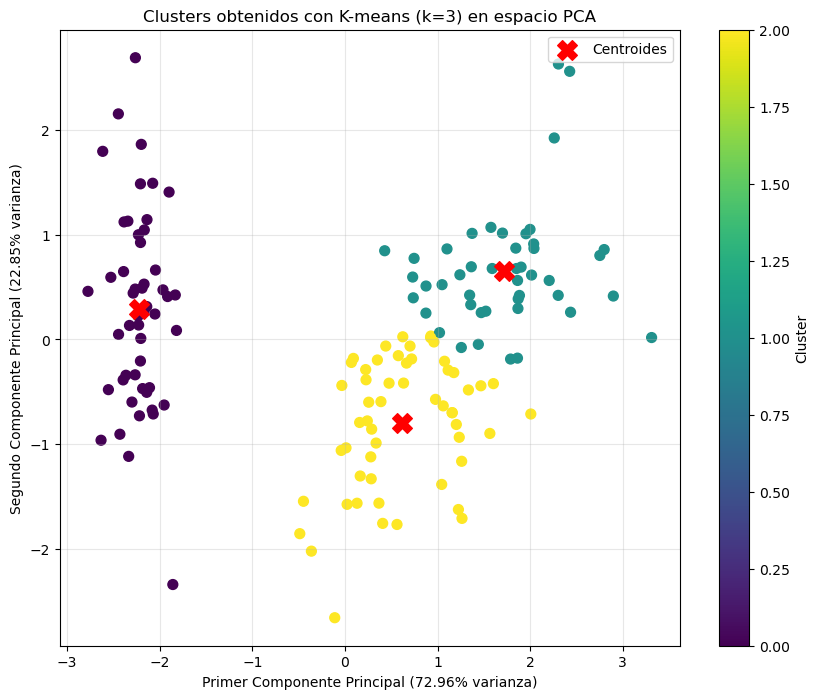

In [37]:
optimal_k = 3  # Según los resultados, k=3 es óptimo

kmeans_final = KMeans(n_clusters=optimal_k, init="k-means++", random_state=2, n_init=10)
clusters = kmeans_final.fit_predict(fields_pca)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(fields_pca[:, 0], fields_pca[:, 1], c=clusters, cmap='viridis', s=50)
plt.scatter(kmeans_final.cluster_centers_[:, 0], kmeans_final.cluster_centers_[:, 1], 
            s=200, c='red', marker='X', label='Centroides')
plt.title(f'Clusters obtenidos con K-means (k={optimal_k}) en espacio PCA')
plt.xlabel(f'Primer Componente Principal ({pca.explained_variance_ratio_[0]:.2%} varianza)')
plt.ylabel(f'Segundo Componente Principal ({pca.explained_variance_ratio_[1]:.2%} varianza)')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [38]:
print("\n=== COMPARACIÓN CON ESPECIES REALES ===")
print(pd.crosstab(clusters, dataset['variety']))


=== COMPARACIÓN CON ESPECIES REALES ===
variety  Setosa  Versicolor  Virginica
row_0                                 
0            50           0          0
1             0          11         34
2             0          39         16
